In [131]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [132]:
font_path = "/home/z3536241/Fonts/arial.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

plt.rcParams['svg.fonttype'] = 'none'

## load layouts and check via plotting

In [133]:
Experiment1Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mAC_mACmCh_TotalPolII/260518_mAC_mACmCh_TotalPolII/METADATA/260518_mAC_mACmCh_TotalPolII.csv")
Experiment2Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mAC_mACmCh_TotalPolII/260601_mAC_mACmCh_TotalPolII/METADATA/260601_mAC_mACmCh_TotalPolII.csv")

## load quantifcation files and assemble as individual dataframes

In [134]:
Experiment1_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260518_mAC_mACmCh_TotalPolII/20260524_154125_815/QUANTIFICATION")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260601_mAC_mACmChPOLR2A_TotalPolII/20260609_153400_658/QUANTIFICATION/")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files)

(960, 912)

In [135]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL": Experiment1_PerCell['well'],
    "IF_647_Intensity": Experiment1_PerCell['Channel:0:0_intensity_mean_647'],
    "RFP_561_Intensity": Experiment1_PerCell['Channel:0:0_intensity_mean_561'],
    "GFP_488_Intensity": Experiment1_PerCell['Channel:0:0_intensity_mean_488'],
    "DAPI_Intensity": Experiment1_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea": Experiment1_PerCell['Channel:0:0_area']
})

100%|██████████| 960/960 [00:05<00:00, 177.73it/s]


In [136]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Channel:0:0_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment2_PerCell['Channel:0:0_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Channel:0:0_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Channel:0:0_area']
})

100%|██████████| 912/912 [00:13<00:00, 67.54it/s]


In [137]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '260518_mAC_mACmCh_TotalPolII'

CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '260601_mAC_mACmCh_TotalPolII'

## save intensity well means to csv

In [138]:
IntensitiesByWell_Experiment1.to_csv("260518_mAC_mACmCh_TotalPolII/SUMMARY/260518_mAC_mACmCh_TotalPolII_intensity_well_mean.csv")
IntensitiesByWell_Experiment2.to_csv("260601_mAC_mACmCh_TotalPolII/SUMMARY/260601_mAC_mACmCh_TotalPolII_intensity_well_mean.csv")

## examine raw data per experiment

In [139]:
IntensitiesByWell_Experiment1.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A Clone 5',
       'HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1'], dtype=object)

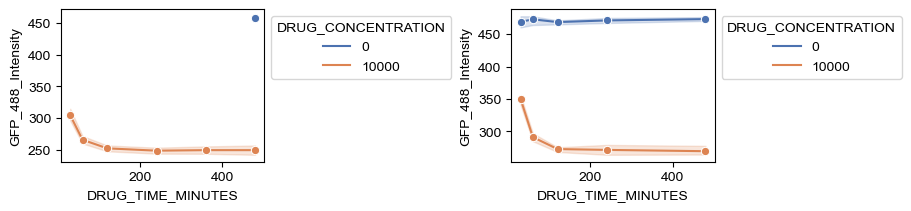

In [140]:
f, a = plt.subplots(ncols = 2, figsize = (9,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

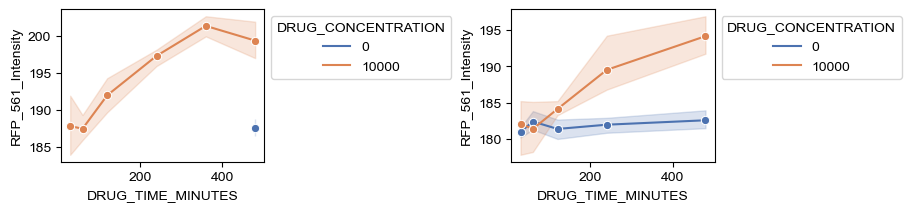

In [141]:
f, a = plt.subplots(ncols = 2, figsize = (9,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

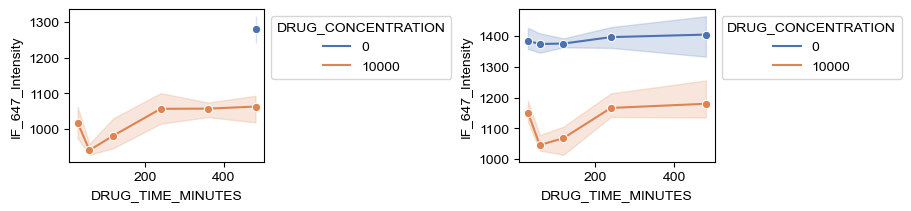

In [142]:
f, a = plt.subplots(ncols = 2, figsize = (9,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

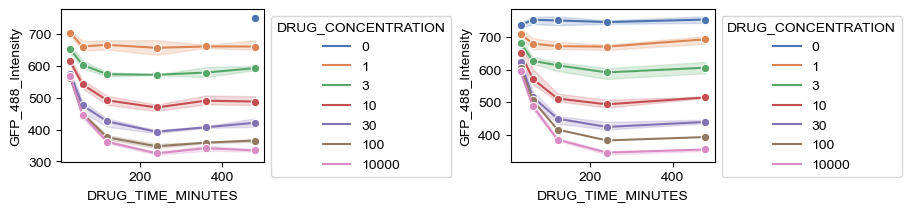

In [143]:
f, a = plt.subplots(ncols = 2, figsize = (9,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

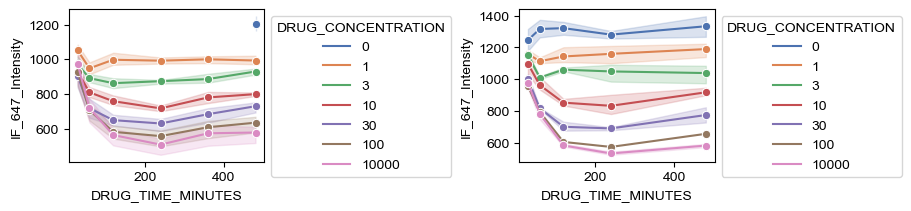

In [144]:
f, a = plt.subplots(ncols = 2, figsize = (9,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
             x = 'DRUG_TIME_MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG_CONCENTRATION', palette = 'deep',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

## background subtract and normalise within each experiment

In [145]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_488_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_488_Intensity'] - E2_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV

In [146]:
E1_RFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').RFP_561_Intensity.mean()
E2_RFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').RFP_561_Intensity.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_561_Intensity'] - E1_RFP_Zero
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_561_Intensity'] - E2_RFP_Zero

E1_RFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E2_RFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_FC'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / E1_RFP_NV
IntensitiesByWell_Experiment2['RFP_Intensity_FC'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / E2_RFP_NV

In [147]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])

In [148]:
E1_IF_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()
E2_IF_Zero = 161.8488

IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment1['IF_647_Intensity'] - E1_IF_Zero
IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment2['IF_647_Intensity'] - E2_IF_Zero

In [152]:
E1_IF_Zero

160.20344986980413

In [170]:
mACmCh_Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1" & PRIMARY == "Total Pol II (F12)"')
mACmCh_Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1" & PRIMARY == "Total Pol II (F12)"')

E1_mACmCh_Total_NV = mACmCh_Total_IntensitiesByWell_Experiment1.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
E2_mACmCh_Total_NV = mACmCh_Total_IntensitiesByWell_Experiment2.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()

mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACmCh_Total_NV
mACmCh_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] / E2_mACmCh_Total_NV

mACmCh_Total_IntensitiesByWell = pd.concat([mACmCh_Total_IntensitiesByWell_Experiment1, mACmCh_Total_IntensitiesByWell_Experiment2])

/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_179623/3517050404.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACmCh_Total_NV
/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_179623/3517050404.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACmCh_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Exper

In [171]:
mACPOLR2A_Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & PRIMARY == "Total Pol II (F12)"')
mACPOLR2A_Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & PRIMARY == "Total Pol II (F12)"')

E1_mACPOLR2A_Total_NV = mACPOLR2A_Total_IntensitiesByWell_Experiment1.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
E2_mACPOLR2A_Total_NV = mACPOLR2A_Total_IntensitiesByWell_Experiment2.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()

mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACPOLR2A_Total_NV 
mACPOLR2A_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] / E2_mACPOLR2A_Total_NV 

mACPOLR2A_Total_IntensitiesByWell = pd.concat([mACPOLR2A_Total_IntensitiesByWell_Experiment1, mACPOLR2A_Total_IntensitiesByWell_Experiment2])

/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_179623/4147847899.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACPOLR2A_Total_NV
/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_179623/4147847899.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACPOLR2A_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACPOLR2A_Total_Intensit

## fold vehicle treated wells into 0 timepoint

In [172]:
IntensitiesByWell = IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "5PhIAA"')
mACmCh_Total_IntensitiesByWell = mACmCh_Total_IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "5PhIAA"')
mACPOLR2A_Total_IntensitiesByWell = mACPOLR2A_Total_IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "5PhIAA"')

In [173]:
IntensitiesByWell['TIME_HOURS'] = IntensitiesByWell['DRUG_TIME_MINUTES'].astype(int) / 60
mACmCh_Total_IntensitiesByWell['TIME_HOURS'] = mACmCh_Total_IntensitiesByWell['DRUG_TIME_MINUTES'].astype(int) / 60
mACPOLR2A_Total_IntensitiesByWell['TIME_HOURS'] = mACPOLR2A_Total_IntensitiesByWell['DRUG_TIME_MINUTES'].astype(int) / 60

In [174]:
def time_in_aux(c, t):
    if c == 0:
        return 0
    elif c > 0:
        return t

In [175]:
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell.apply(lambda x: time_in_aux(x.DRUG_CONCENTRATION, x.TIME_HOURS), axis = 1)
mACmCh_Total_IntensitiesByWell['TIME_IN_AUXIN'] = mACmCh_Total_IntensitiesByWell.apply(lambda x: time_in_aux(x.DRUG_CONCENTRATION, x.TIME_HOURS), axis = 1)
mACPOLR2A_Total_IntensitiesByWell['TIME_IN_AUXIN'] = mACPOLR2A_Total_IntensitiesByWell.apply(lambda x: time_in_aux(x.DRUG_CONCENTRATION, x.TIME_HOURS), axis = 1)

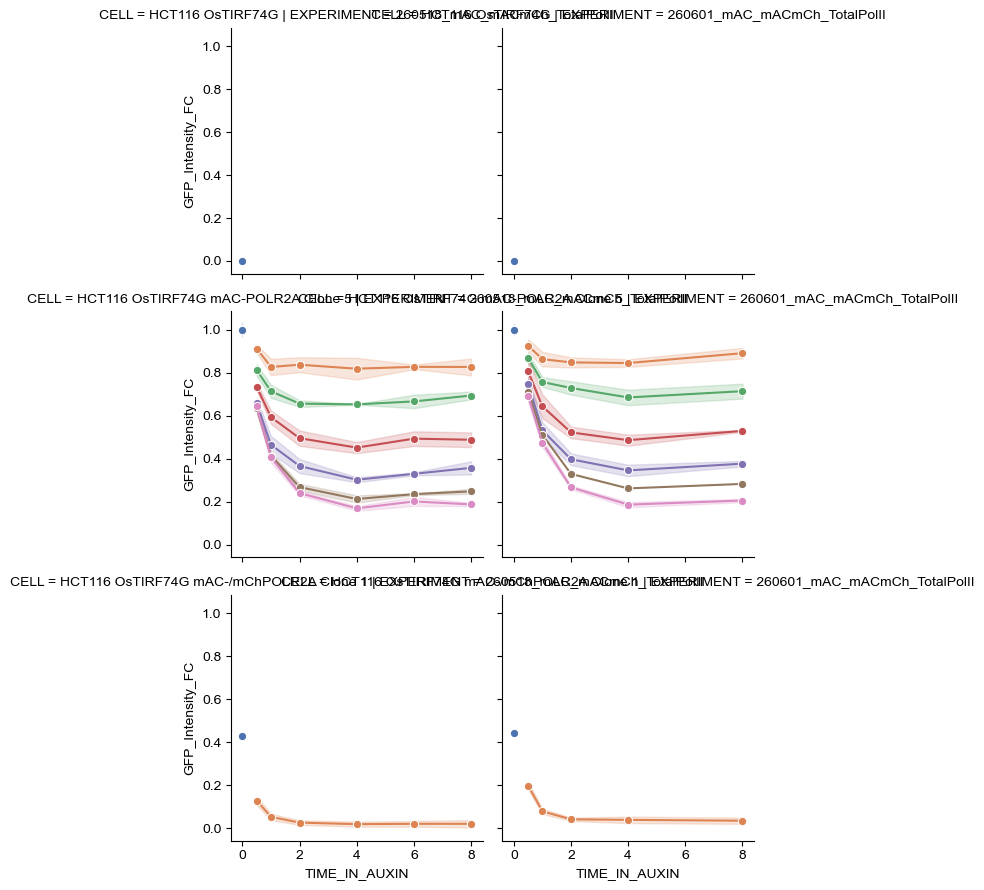

In [168]:
g = sns.FacetGrid(IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'CELL')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'GFP_Intensity_FC',
                hue = 'DRUG_CONCENTRATION', palette = 'deep',
                marker = 'o',
                errorbar = 'sd')

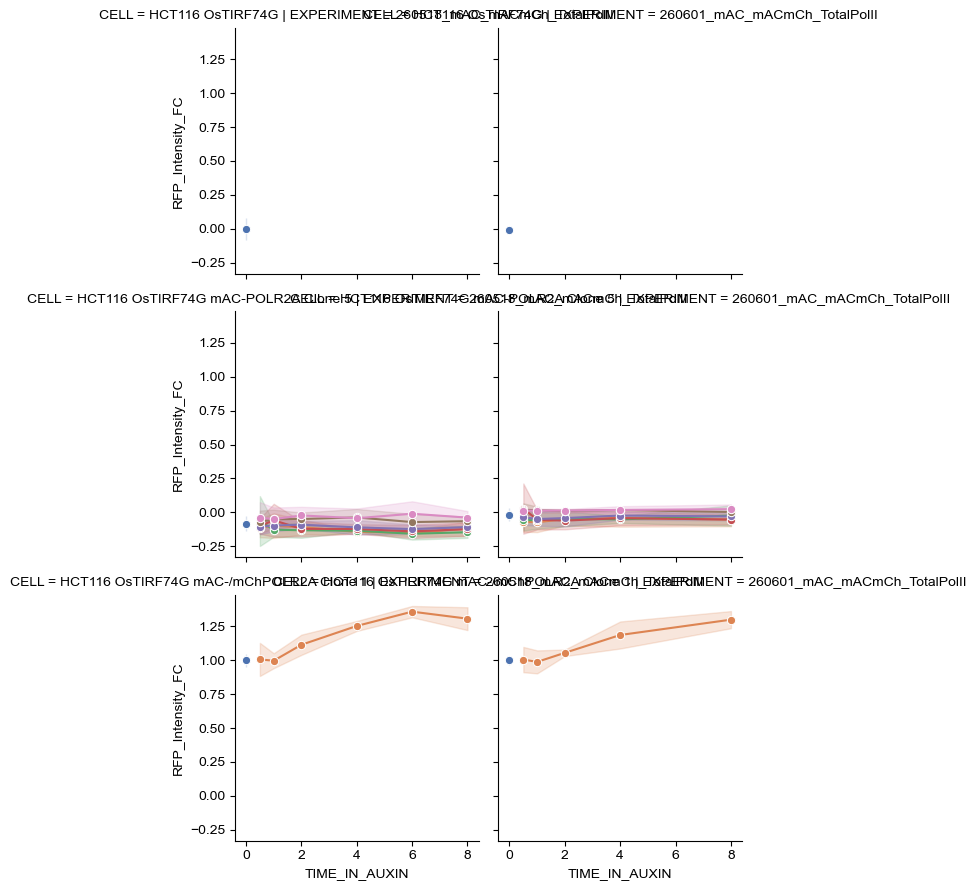

In [162]:
g = sns.FacetGrid(IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'CELL')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'RFP_Intensity_FC',
                hue = 'DRUG_CONCENTRATION', palette = 'deep',
                marker = 'o',
                errorbar = 'sd')

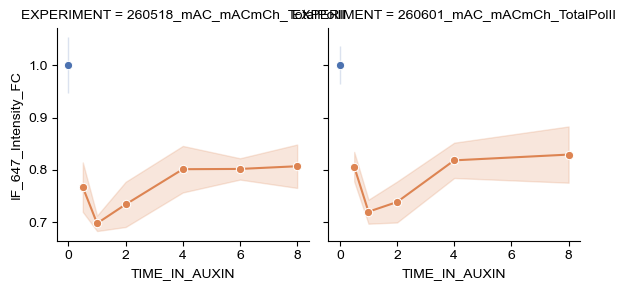

In [176]:
g = sns.FacetGrid(mACmCh_Total_IntensitiesByWell,
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'IF_647_Intensity_FC',
                hue = 'DRUG_CONCENTRATION', palette = 'deep',
                marker = 'o',
                errorbar = 'sd')

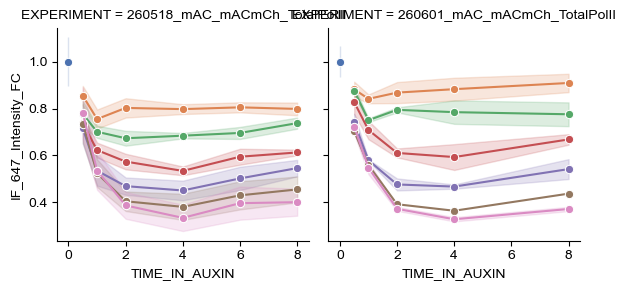

In [177]:
g = sns.FacetGrid(mACPOLR2A_Total_IntensitiesByWell,
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'IF_647_Intensity_FC',
                hue = 'DRUG_CONCENTRATION', palette = 'deep',
                marker = 'o',
                errorbar = 'sd')

## filter for timepoints common to both experiments

In [207]:
IntensitiesByWell.TIME_IN_AUXIN.unique()

array([0. , 0.5, 1. , 2. , 4. , 6. , 8. ])

In [209]:
IntensitiesByWell = IntensitiesByWell.query('TIME_IN_AUXIN in [0. , 0.5, 1. , 2. , 4. , 8. ]')
mACmCh_Total_IntensitiesByWell = mACmCh_Total_IntensitiesByWell.query('TIME_IN_AUXIN in [0. , 0.5, 1. , 2. , 4. , 8. ]')
mACPOLR2A_Total_IntensitiesByWell = mACPOLR2A_Total_IntensitiesByWell.query('TIME_IN_AUXIN in [0. , 0.5, 1. , 2. , 4. , 8. ]')

# Plots for manuscript

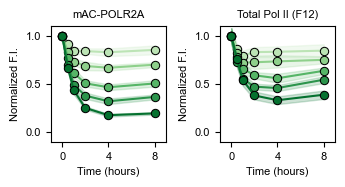

In [233]:
f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

a[0].set_title('mAC-POLR2A', fontsize = 8)

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION in [0,1]'),
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = sns.color_palette('Greens')[1],
             legend = False)
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION in [0,3]'),
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = sns.color_palette('Greens')[2],
             legend = False)
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION in [0,10]'),
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = sns.color_palette('Greens')[3],
             legend = False)
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION in [0,30]'),
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = sns.color_palette('Greens')[4],
             legend = False)
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION in [0,10000]'),
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = sns.color_palette('Greens')[5],
             legend = False)


a[1].set_title('Total Pol II (F12)', fontsize = 8)
sns.lineplot(mACPOLR2A_Total_IntensitiesByWell.query('DRUG_CONCENTRATION in [0,1]'),
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = sns.color_palette('Greens')[1],
             legend = False)
sns.lineplot(mACPOLR2A_Total_IntensitiesByWell.query('DRUG_CONCENTRATION in [0,3]'),
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = sns.color_palette('Greens')[2],
             legend = False)
sns.lineplot(mACPOLR2A_Total_IntensitiesByWell.query('DRUG_CONCENTRATION in [0,10]'),
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = sns.color_palette('Greens')[3],
             legend = False)
sns.lineplot(mACPOLR2A_Total_IntensitiesByWell.query('DRUG_CONCENTRATION in [0,30]'),
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = sns.color_palette('Greens')[4],
             legend = False)

sns.lineplot(mACPOLR2A_Total_IntensitiesByWell.query('DRUG_CONCENTRATION in [0,10000]'),
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = sns.color_palette('Greens')[5],
             legend = False)



for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1)
    a[i].set_ylim(-0.1,1.1)
    a[i].set_yticks([0, 0.5, 1])
    a[i].set_xticks([0,4,8])
    a[i].set_xlim(-1, 9)
    a[i].tick_params(axis='both', labelsize=8)

plt.savefig('mACPOLR2A_GFP_TotalPolII_concentrations.svg')

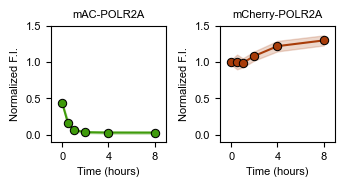

In [234]:
f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

a[0].set_title('mAC-POLR2A', fontsize = 8)
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

a[1].set_title('mCherry-POLR2A', fontsize = 8)
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-/mChPOLR2A Clone 1"'),
             x = 'TIME_IN_AUXIN', 
             y = 'RFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'xkcd:rust', 
             legend = False)


for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1)
    a[i].set_ylim(-0.1,1.5)
    a[i].set_yticks([0, 0.5, 1, 1.5])
    a[i].set_xticks([0,4,8])
    a[i].set_xlim(-1, 9)
    a[i].tick_params(axis='both', labelsize=8)

plt.savefig('mACmCherryPOLR2A_GFP_RFP.svg')

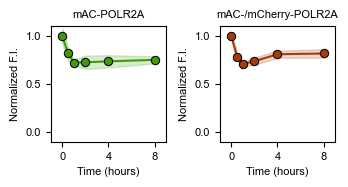

In [235]:
f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

a[0].set_title('mAC-POLR2A', fontsize = 8)
sns.lineplot(mACPOLR2A_Total_IntensitiesByWell.query('DRUG_CONCENTRATION in [0,3]'),
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

a[1].set_title('mAC-/mCherry-POLR2A', fontsize = 8)
sns.lineplot(mACmCh_Total_IntensitiesByWell,
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'xkcd:rust', 
             legend = False)


for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1)
    a[i].set_ylim(-0.1,1.1)
    a[i].set_yticks([0, 0.5, 1])
    a[i].set_xticks([0,4,8])
    a[i].set_xlim(-1, 9)
    a[i].tick_params(axis='both', labelsize=8)

plt.savefig('mAC_mACmChPOLR2A_TotalPolII.svg')

In [ ]:
f, a = plt.subplots(ncols = 2, figsize = (3,1.5), layout = 'constrained')

sns.set_context('paper')

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'), 
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'TIME_IN_AUXIN', 
             y = 'RFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:rust', 
             legend = False)

sns.lineplot(mACPOLR2A_Total_IntensitiesByWell, 
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'orange', 
             legend = False)


for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.75)
    a[i].set_ylim(-0.1,1.1)
    a[i].set_yticks([0, 0.5, 1])
    a[i].set_xticks(np.linspace(0,24,5))
    a[i].set_xlim(-2, 26)
    a[i].tick_params(axis='both', labelsize=8)

#plt.savefig('mACmChPOLR2A_GFP_RFP_TotalPolII.svg')

In [ ]:
f, a = plt.subplots(ncols = 2, figsize = (3,1.5), layout = 'constrained')

sns.set_context('paper')

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'), 
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

sns.lineplot(mACPOLR2A_Total_IntensitiesByWell, 
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'orange', 
             legend = False)


for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.75)
    a[i].set_ylim(-0.1,1.1)
    a[i].set_yticks([0, 0.5, 1])
    a[i].set_xticks(np.linspace(0,24,5))
    a[i].set_xlim(-2, 26)
    a[i].tick_params(axis='both', labelsize=8)

plt.savefig('mACPOLR2A_GFP_TotalPolII.svg')